In [3]:
import sys
from types import ModuleType

# Workaround to mock all optional SpeechBrain packages and prevent Jupyter autoreload crashes
for target in [
    'speechbrain.integrations.k2_fsa',
    'speechbrain.integrations.nlp',
    'speechbrain.integrations.fairseq',
    'speechbrain.integrations.onnx',
    'speechbrain.integrations.pytorch_geometric'
]:
    if target not in sys.modules:
        sys.modules[target] = ModuleType(target.split('.')[-1])

# Now import the rest of your libraries
from langgraph.graph import StateGraph, START, END
# ... rest of your code ...

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal, List
from langgraph.graph import StateGraph, START, END

load_dotenv()

d:\factlens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [5]:
class DetectorResult(TypedDict, total=False):
    audio_languages: List[str]
    ocr_languages: List[str]

In [24]:
class Segment(TypedDict):
    start: float
    end: float
    text: str
    confidence: float

In [33]:
class Segment1(TypedDict):
    start: float
    end: float
    text: str
    context: float

In [ ]:
# state
class FactLensState(TypedDict):
    video_path: str # given by user
    video_name: str
    video_size: int
    video_duration: Optional[float]

    valid: Literal[True, False]
    readable: Literal[True, False]
    error: str

    filename: str
    extension: Literal[".mp4", ".mov", ".mkv"]
    mime_type: str
    file_size_bytes: int
    file_size_mb: float
    duration_seconds: float
    fps: float
    frame_count: float
    resolution: str

    # store individual detector outputs
    whisper_result: DetectorResult
    mms_result: DetectorResult
    vox_result: DetectorResult
    speechbrain_result: DetectorResult

    audio_languages: List[str]
    ocr_languages: List[str]

    audio_path: str

    segments: list[Segment]
    segments_eng : list[Segment]

    frame_paths : List[str]
    ocr_segments: list[Segment1]
    ocr_segments_eng: list[Segment1]

    segments_ocr_audio: 


In [17]:
# function that take the file path and return video file

from pathlib import Path

def get_video_file(file_path: str):
    """
    Returns an opened video file object if it exists.
    Returns None if the file doesn't exist.
    """
    path = Path(file_path)

    if not path.exists():
        print(f"File not found: {file_path}")
        return None

    return open(path, "rb")

In [18]:
import os
import cv2
import mimetypes


def metadata_extraction_node(state: FactLensState) -> dict:
    video_path = state["video_path"]

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    filename = os.path.basename(video_path)
    extension = os.path.splitext(filename)[1].lower()
    mime_type, _ = mimetypes.guess_type(video_path)
    file_size = os.path.getsize(video_path)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {
            "valid": False,
            "readable": False,
            "error": "Unable to open video."
        }

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    # Extract the audio ONCE here before starting parallel detection
    try:
        audio_path = extract_audio(video_path)
    except Exception as e:
        return {
            "valid": False,
            "readable": False,
            "error": f"Audio extraction failed: {str(e)}"
        }

    return {
        "valid": True,
        "filename": filename,
        "extension": extension,
        "mime_type": mime_type,
        "file_size_bytes": file_size,
        "file_size_mb": round(file_size / (1024 * 1024), 2),
        "duration_seconds": round(duration, 2),
        "fps": round(fps, 2),
        "frame_count": frame_count,
        "resolution": f"{width}x{height}",
        "readable": True,
        "audio_path": audio_path, # Saved to state
    }

In [19]:
import os
import tempfile
import subprocess
from collections import Counter

import cv2
import torch
import librosa
import whisper
import easyocr
from langdetect import detect_langs
from transformers import Wav2Vec2ForSequenceClassification, AutoFeatureExtractor
from speechbrain.inference.classifiers import EncoderClassifier

# Mapping ISO-639-3 (3-letter) outputs from facebook/mms-lid-401 to ISO-639-1 (2-letter)
MMS_ISO_MAP = {
    "hin": "hi", "eng": "en", "urd": "ur", "guj": "gu",
    "pan": "pa", "bng": "bn", "tam": "ta", "tel": "te",
    "kan": "kn", "mal": "ml", "mar": "mr", "ori": "or",
    "spa": "es", "fra": "fr", "deu": "de", "ita": "it",
    "rus": "ru", "zho": "zh", "jpn": "ja", "kor": "ko",
    "ara": "ar", "tur": "tr", "por": "pt", "vie": "vi"
}
# =====================================================================
# 2. AUDIO & OCR EXTRACTION HELPERS
# =====================================================================
import os
import subprocess

def extract_audio(file_path: str) -> str:
    """Extracts audio from video and saves it to the temp1 folder as 16kHz mono WAV."""

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Input file not found at: {file_path}")

    ext = os.path.splitext(file_path)[1].lower()
    if ext in [".wav", ".mp3", ".m4a", ".flac", ".ogg"]:
        return file_path

    # Create temp1 folder in the current working directory
    temp_dir = "temp1"
    os.makedirs(temp_dir, exist_ok=True)

    # Output audio path
    audio_name = f"{os.path.splitext(os.path.basename(file_path))[0]}.wav"
    temp_audio_path = os.path.join(temp_dir, audio_name)

    # Remove existing file if present
    if os.path.exists(temp_audio_path):
        try:
            os.remove(temp_audio_path)
        except Exception:
            pass

    cmd = [
        "ffmpeg",
        "-y",
        "-i", file_path,
        "-vn",
        "-acodec", "pcm_s16le",
        "-ar", "16000",
        "-ac", "1",
        temp_audio_path,
    ]

    try:
        subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            check=True,
        )
    except Exception as e:
        raise RuntimeError(f"FFmpeg audio extraction failed: {str(e)}")

    return temp_audio_path
def detect_ocr_languages(video_path: str) -> List[str]:
    """
    Runs separate compatible EasyOCR readers on video frames to detect 
    languages present in the visual text without script conflicts.
    """
    if not os.path.exists(video_path):
        return []
        
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30
        
    frame_interval = int(fps * 2)
    frame_count = 0
    extracted_texts = []
    
    # Initialize separate readers to avoid Devanagari (Hindi) and Arabic (Urdu) conflicts
    use_gpu = torch.cuda.is_available()
    reader_hi = easyocr.Reader(['en', 'hi'], gpu=use_gpu)
    reader_ur = easyocr.Reader(['en', 'ur'], gpu=use_gpu)
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_count % frame_interval == 0:
            # 1. Run Hindi / English OCR
            res_hi = reader_hi.readtext(frame, detail=0)
            if res_hi:
                extracted_texts.extend(res_hi)
                
            # 2. Run Urdu / English OCR
            res_ur = reader_ur.readtext(frame, detail=0)
            if res_ur:
                extracted_texts.extend(res_ur)
                
        frame_count += 1
        if frame_count > fps * 30:
            break
            
    cap.release()
    
    combined_text = " ".join(extracted_texts).strip()
    if not combined_text:
        return []
        
    detected_languages = []
    try:
        predictions = detect_langs(combined_text)
        for pred in predictions:
            if pred.prob > 0.2:
                detected_languages.append(pred.lang)
    except Exception:
        pass
        
    return sorted(list(set(detected_languages)))
# =====================================================================
# 3. ACTUAL MODEL CLASSIFICATION LOGIC
# =====================================================================
def run_whisper_audio(audio_path: str) -> List[str]:
    try:
        model = whisper.load_model("tiny")
        audio = whisper.load_audio(audio_path)
        audio = whisper.pad_or_trim(audio)
        
        mel = whisper.log_mel_spectrogram(audio).to(model.device)
        _, probs = model.detect_language(mel)
        detected = max(probs, key=probs.get)
        return [detected] if detected else []
    except Exception as e:
        print(f"[Whisper Error] {e}")
        return []
    
def run_mms_audio(audio_path: str) -> List[str]:
    """Facebook MMS-LID-4017 Hugging Face model execution to detect language."""
    try:
        # Corrected model identifier: added '7' to the end
        model_name = "facebook/mms-lid-4017"
        processor = AutoFeatureExtractor.from_pretrained(model_name)
        model = Wav2Vec2ForSequenceClassification.from_pretrained(model_name)
        
        speech, _ = librosa.load(audio_path, sr=16000)
        inputs = processor(speech, sampling_rate=16000, return_tensors="pt")
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        predicted_id = torch.argmax(outputs.logits, dim=-1).item()
        lang_3 = model.config.id2label[predicted_id]
        
        lang_2 = MMS_ISO_MAP.get(lang_3.lower(), lang_3)
        return [lang_2] if lang_2 else []
    except Exception as e:
        print(f"[MMS Error] {e}")
        return []


def run_speechbrain_audio(audio_path: str) -> List[str]:
    """CommonLanguage ECAPA model execution via SpeechBrain."""
    try:
        # Save model inside local project directory to help avoid Windows cross-volume symlink errors
        model_dir = "./model_cache/sb_cv"
        
        # Corrected model identifier to the public commonlanguage_ecapa model
        classifier = EncoderClassifier.from_hparams(
            source="speechbrain/lang-id-commonlanguage_ecapa", 
            savedir=model_dir
        )
        signal = classifier.load_audio(audio_path)
        prediction = classifier.classify_batch(signal)
        label = prediction[3][0]
        detected = label.split(":")[0].strip()
        return [detected] if detected else []
    except Exception as e:
        print(f"[SpeechBrain Error] {e}")
        return []


def run_voxlingua_audio(audio_path: str) -> List[str]:
    """VoxLingua107 ECAPA-TDNN model execution via SpeechBrain."""
    try:
        # Save model inside local project directory to help avoid Windows cross-volume symlink errors
        model_dir = "./model_cache/sb_vox"
        
        classifier = EncoderClassifier.from_hparams(
            source="speechbrain/lang-id-voxlingua107-ecapa", 
            savedir=model_dir
        )
        signal = classifier.load_audio(audio_path)
        prediction = classifier.classify_batch(signal)
        label = prediction[3][0]
        detected = label.split(":")[0].strip()
        return [detected] if detected else []
    except Exception as e:
        print(f"[VoxLingua Error] {e}")
        return []
# =====================================================================
# 4. PARALLEL NODES (Corrected to use video_path)
# =====================================================================
def whisper_audio_detection(state: FactLensState) -> dict:
    video_path = state.get("video_path")
    audio_path = state.get("audio_path")
    if not video_path or not audio_path:
        return {"whisper_result": {"audio_languages": [], "ocr_languages": []}}
    
    audio_langs = run_whisper_audio(audio_path)
    ocr_langs = detect_ocr_languages(video_path)
    
    return {
        "whisper_result": {
            "audio_languages": audio_langs,
            "ocr_languages": ocr_langs
        }
    }
def mms_lid_401_audio_detection(state: FactLensState) -> dict:
    video_path = state.get("video_path")
    audio_path = state.get("audio_path")
    if not video_path or not audio_path:
        return {"mms_result": {"audio_languages": [], "ocr_languages": []}}
    
    audio_langs = run_mms_audio(audio_path)
    ocr_langs = detect_ocr_languages(video_path)
    
    return {
        "mms_result": {
            "audio_languages": audio_langs,
            "ocr_languages": ocr_langs
        }
    }

def voxlingua107_audio_detection(state: FactLensState) -> dict:
    video_path = state.get("video_path")
    audio_path = state.get("audio_path")
    if not video_path or not audio_path:
        return {"vox_result": {"audio_languages": [], "ocr_languages": []}}
    
    audio_langs = run_voxlingua_audio(audio_path)
    ocr_langs = detect_ocr_languages(video_path)
    
    return {
        "vox_result": {
            "audio_languages": audio_langs,
            "ocr_languages": ocr_langs
        }
    }
def speechbrain_audio_detection(state: FactLensState) -> dict:
    video_path = state.get("video_path")
    audio_path = state.get("audio_path")
    if not video_path or not audio_path:
        return {"speechbrain_result": {"audio_languages": [], "ocr_languages": []}}
    
    audio_langs = run_speechbrain_audio(audio_path)
    ocr_langs = detect_ocr_languages(video_path)
    
    return {
        "speechbrain_result": {
            "audio_languages": audio_langs,
            "ocr_languages": ocr_langs
        }
    }
# =====================================================================
# 5. CONSOLIDATING / MERGER NODE LOGIC
# =====================================================================
def flatten_languages(audio_lists: List[List[str]]) -> List[str]:
    return [lang for sublist in audio_lists if sublist for lang in sublist if lang]
def majority_vote(state: FactLensState) -> List[str]:
    priority_keys = ["mms_result", "speechbrain_result", "vox_result", "whisper_result"]
    audio_lists = []
    
    for key in priority_keys:
        res = state.get(key)
        if isinstance(res, dict):
            audio_lists.append(res.get("audio_languages", []))
        else:
            audio_lists.append([])
            
    flattened = flatten_languages(audio_lists)
    if not flattened:
        return []
        
    counter = Counter(flattened)
    max_count = max(counter.values())
    candidates = [lang for lang, count in counter.items() if count == max_count]
    
    if len(candidates) == 1:
        return [candidates[0]]
        
    candidate_best_priority = {}
    for cand in candidates:
        for idx, key in enumerate(priority_keys):
            res = state.get(key)
            if isinstance(res, dict) and cand in res.get("audio_languages", []):
                candidate_best_priority[cand] = idx
                break
        else:
            candidate_best_priority[cand] = len(priority_keys)
            
    winner = min(candidates, key=lambda c: candidate_best_priority[c])
    return [winner]
def merge_ocr_languages(state: FactLensState) -> List[str]:
    keys = ["mms_result", "speechbrain_result", "vox_result", "whisper_result"]
    ocr_lists = []
    for key in keys:
        res = state.get(key)
        if isinstance(res, dict):
            ocr_lists.append(res.get("ocr_languages", []))
            
    flattened = flatten_languages(ocr_lists)
    return sorted(list(set(flattened)))
def final_audio_selection(state: FactLensState) -> dict:
    final_audio = majority_vote(state)
    final_ocr = merge_ocr_languages(state)
    
    return {
        "audio_languages": final_audio,
        "ocr_languages": final_ocr
    }

In [ ]:
# ignore it =========================================================

import os
import cv2
import tempfile
from collections import Counter

from rapidocr_onnxruntime import RapidOCR
from langdetect import detect, LangDetectException
from faster_whisper import WhisperModel
from moviepy import VideoFileClip


# Initialize once
ocr = RapidOCR()
whisper = WhisperModel("base", device="cpu")


def language_detection_node(state: FactLensState) -> dict:
    """
    Detect all languages present in audio and OCR.

    Returns:
    {
        "audio_languages": ["en", "hi"],
        "ocr_languages": ["en"]
    }
    """

    video_path = state["video_path"]

    # =====================================================
    # AUDIO LANGUAGE DETECTION (Highest Priority)
    # =====================================================

    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        audio_path = tmp.name

    try:

        VideoFileClip(video_path).audio.write_audiofile(
            audio_path,
            logger=None
        )

        segments, _ = whisper.transcribe(
            audio_path,
            vad_filter=True
        )

        audio_counter = Counter()

        buffer = ""

        # Merge transcript into larger chunks
        for segment in segments:

            text = segment.text.strip()

            if not text:
                continue

            buffer += " " + text

            # Detect every ~250 characters
            if len(buffer) >= 250:

                try:
                    lang = detect(buffer)
                    audio_counter[lang] += 1
                except LangDetectException:
                    pass

                buffer = ""

        # Remaining text
        if buffer.strip():
            try:
                lang = detect(buffer)
                audio_counter[lang] += 1
            except LangDetectException:
                pass

    finally:

        if os.path.exists(audio_path):
            os.remove(audio_path)

    # Keep every detected language
    audio_languages = sorted(audio_counter.keys())

    # =====================================================
    # OCR LANGUAGE DETECTION (Lightweight)
    # =====================================================

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Only one frame every 3 seconds
    sample_interval = max(1, int(fps * 3))

    ocr_counter = Counter()

    for frame_no in range(0, total_frames, sample_interval):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)

        success, frame = cap.read()

        if not success:
            continue

        result, _ = ocr(frame)

        if not result:
            continue

        text = " ".join(
            line[1]
            for line in result
        ).strip()

        if len(text) < 10:
            continue

        try:
            lang = detect(text)
            ocr_counter[lang] += 1
        except LangDetectException:
            pass

    cap.release()

    # Keep languages seen at least twice
    ocr_languages = sorted([
        lang
        for lang, count in ocr_counter.items()
        if count >= 2
    ])

    return {
        "audio_languages": audio_languages,
        "ocr_languages": ocr_languages
    }

In [26]:
from faster_whisper import WhisperModel


def transcribe_audio(state : FactLensState) -> FactLensState:
    """
    Transcribes an audio file using Faster-Whisper.

    Args:
        audio_path (str): Path to the audio file.
        model_size (str): Whisper model size (tiny, base, small, medium, large-v3)

    Returns:
        list: A list of transcription segments in the format:
        [
            {
                "start": float,
                "end": float,
                "text": str,
                "confidence": float
            }
        ]
    """

    model_size = "small"
    audio_path = state["audio_path"]

    # Load model (CPU)
    model = WhisperModel(
        model_size,
        device="cpu",
        compute_type="int8"
    )

    # Transcribe
    whisper_segments, info = model.transcribe(
        audio_path,
        beam_size=5,
        vad_filter=True
    )

    segments = []

    for segment in whisper_segments:
        # Convert average log probability to confidence (0-1)
        confidence = round(
            min(max(pow(2.71828, segment.avg_logprob), 0.0), 1.0),
            4
        )

        segments.append({
            "start": round(segment.start, 2),
            "end": round(segment.end, 2),
            "text": segment.text.strip(),
            "confidence": confidence
        })

    return {"segments" : segments}

In [28]:
from copy import deepcopy
from langchain_google_genai import ChatGoogleGenerativeAI


# Initialize once and reuse
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


def translate_segments_to_english(state : FactLensState) -> FactLensState:
    """
    Translate the 'text' field of each segment to English.

    Args:
        segments: List of segment dictionaries.
        source_language: Detected language (e.g., "Hindi", "Urdu", "English").

    Returns:
        List of segments with translated English text.
    """
    segments = state["segments"]
    source_language = state["audio_languages"]

    # If already English, return unchanged
    if source_language.strip().lower() in {
        "english", "en", "eng"
    }:
        return deepcopy(segments)

    translated_segments = []

    for segment in segments:

        prompt = f"""
Translate the following {source_language} text into natural English.

Rules:
- Return ONLY the English translation.
- Do not explain anything.
- Do not summarize.
- Preserve the original meaning.

Text:
{segment["text"]}
"""

        translated_text = llm.invoke(prompt).content.strip()

        translated_segment = {
            "start": segment["start"],
            "end": segment["end"],
            "text": translated_text,
            "confidence": segment["confidence"],
        }

        translated_segments.append(translated_segment)

    return {"segments_eng" : translated_segments}

In [31]:
import os
import cv2


def extract_frames(state : FactLensState) -> FactLensState:
    """
    Extract frames from a video every N seconds.

    Args:
        video_path (str): Path to the input video.
        interval_seconds (float): Time interval between frames.

    Returns:
        list[str]: List of extracted frame image paths.
    """

    video_path = state["video_path"]
    interval_seconds = 2.0


    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    # Create temp1/frames directory
    frames_dir = os.path.join("temp1", "frames")
    os.makedirs(frames_dir, exist_ok=True)

    # Remove old frames
    for file in os.listdir(frames_dir):
        file_path = os.path.join(frames_dir, file)
        if os.path.isfile(file_path):
            os.remove(file_path)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError("Could not open video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = max(int(fps * interval_seconds), 1)

    frame_count = 0
    saved_count = 0
    frame_paths = []

    while True:
        success, frame = cap.read()

        if not success:
            break

        if frame_count % frame_interval == 0:
            frame_name = f"frame_{saved_count:04d}.jpg"
            frame_path = os.path.join(frames_dir, frame_name)

            cv2.imwrite(frame_path, frame)
            frame_paths.append(frame_path)

            saved_count += 1

        frame_count += 1

    cap.release()

    return {"frame_paths" : frame_paths}

In [35]:
import base64
import json
import mimetypes
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage


def analyze_frames(state : FactLensState) -> FactLensState:
    """
    Analyze a sequence of video frames (each representing a 2-second segment)
    using Gemini (via langchain_google_genai) and return a list of dicts
    containing timing, on-screen text, and contextual analysis for each frame.

    Args:
        image_paths: Ordered list of frame image paths, e.g.
            [
                "temp1/frames/frame_0000.jpg",
                "temp1/frames/frame_0001.jpg",
                ...
            ]
            Each frame is assumed to represent a 2-second window of video.

    Returns:
        A list of dicts, one per frame, e.g.:
        [
            {
                "start": 0.0,
                "end": 2.0,
                "text": "<on-screen text, in the language shown in the image>",
                "context": "<English description of what the frame is about>"
            },
            ...
        ]
    """

    image_paths = state["frame_paths"]

    SYSTEM_PROMPT = """You are an expert multimodal computer vision system analyzing a single video frame.

You will be shown one image. Carefully examine it and identify:

1. TEXT: Any text visible/written on screen (captions, overlays, signs, UI text, subtitles, headlines, etc). Transcribe it EXACTLY as it appears, in the SAME language/script it is written in the image. If there is no visible text, return an empty string.

2. CONTEXT: A concise but informative description IN ENGLISH of what the frame is about — who appears (e.g. their apparent role, appearance, actions — never confidently name unknown private individuals, but you may identify well-known public figures if clearly recognizable), what is happening, the setting/scene, any relevant objects, logos, or visual clues, and what the frame seems to be communicating. This should give useful context for someone doing fact-checking or video understanding.

IMPORTANT RULES:
- Return ONLY valid JSON. No markdown, no code fences, no explanation, no extra text.
- Do NOT invent or hallucinate text or facts not visible in the image.
- If uncertain about something, note the uncertainty briefly within the context field rather than guessing confidently.
- Keep "text" faithful to the original on-screen language/script.
- Keep "context" in English regardless of the image's language.

Return EXACTLY this JSON structure and nothing else:

{
  "text": "",
  "context": ""
}"""

    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        temperature=0,
    )

    results = []

    for i, image_path in enumerate(image_paths):
        start_time = round(i * 2.0, 2)
        end_time = round(start_time + 2.0, 2)

        try:
            with open(image_path, "rb") as f:
                image_bytes = f.read()
            image_b64 = base64.standard_b64encode(image_bytes).decode("utf-8")
            media_type = mimetypes.guess_type(image_path)[0] or "image/jpeg"

            messages = [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(
                    content=[
                        {
                            "type": "text",
                            "text": "Analyze this video frame and return the JSON as instructed.",
                        },
                        {
                            "type": "image_url",
                            "image_url": f"data:{media_type};base64,{image_b64}",
                        },
                    ]
                ),
            ]

            response = llm.invoke(messages)
            raw_text = (response.content or "").strip()

            # Strip accidental markdown fences
            if raw_text.startswith("```"):
                raw_text = re.sub(r"^```(json)?", "", raw_text).strip()
                raw_text = re.sub(r"```$", "", raw_text).strip()

            try:
                parsed = json.loads(raw_text)
            except json.JSONDecodeError:
                parsed = {"text": "", "context": f"Failed to parse model output: {raw_text}"}

            results.append(
                {
                    "start": start_time,
                    "end": end_time,
                    "text": parsed.get("text", ""),
                    "context": parsed.get("context", ""),
                }
            )

        except Exception as e:
            results.append(
                {
                    "start": start_time,
                    "end": end_time,
                    "text": "",
                    "context": f"Error analyzing frame {image_path}: {e}",
                }
            )

    return {"ocr_segments" : results}

In [ ]:
import json
from copy import deepcopy

from langchain_google_genai import ChatGoogleGenerativeAI


# Initialize once
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


def ocr_texts_to_english(state : FactLensState) -> FactLensState:
    """
    Translate only the 'text' field of every segment to English.

    Input:
    [
        {
            "start": 0.0,
            "end": 2.0,
            "text": "...",
            "context": "..."
        }
    ]

    Output:
    Same structure with only the 'text' translated to English.
    """
    segments = state["ocr_segments"]

    if not segments:
        return {"ocr_segments_eng" : []}

    translated_segments = deepcopy(segments)

    texts = [segment["text"] for segment in segments]

    prompt = f"""
You are a professional translator.

Translate every sentence into natural English.

Rules:
- If a sentence is already in English, return it unchanged.
- Preserve the meaning.
- Do NOT summarize.
- Do NOT explain.
- Do NOT number the outputs.
- Return ONLY a valid JSON array of translated strings.
- The output array MUST contain exactly {len(texts)} strings.

Input:
{json.dumps(texts, ensure_ascii=False)}
"""

    response = llm.invoke(prompt).content.strip()

    # Remove markdown if Gemini returns ```json
    if response.startswith("```"):
        response = response.replace("```json", "").replace("```", "").strip()

    translated_texts = json.loads(response)

    if len(translated_texts) != len(segments):
        raise ValueError(
            "Translation response length does not match input length."
        )

    for segment, translated_text in zip(translated_segments, translated_texts):
        segment["text"] = translated_text

    return {"ocr_segments_eng" : translated_segments}

In [ ]:
from typing import List, Dict


def merge_speech_with_ocr(state : FactLensState) -> FactLensState:
    """
    Merge speech segments with overlapping OCR segments.

    Parameters
    ----------
    speech_segments : list[dict]
        Example:
        {
            "start": 0.0,
            "end": 4.78,
            "text": "...",
            "confidence": 0.679
        }

    ocr_segments : list[dict]
        Example:
        {
            "start": 0.0,
            "end": 2.0,
            "text": "...",
            "context": "..."
        }

    Returns
    -------
    list[dict]
    """

    speech_segments = state["segments_eng"]
    ocr_segments = state["ocr_segments_eng"]

    merged = []

    for speech in speech_segments:
        speech_start = speech["start"]
        speech_end = speech["end"]

        text_seen = set()
        context_seen = set()

        ocr_texts = []
        ocr_contexts = []

        for ocr in ocr_segments:
            ocr_start = ocr["start"]
            ocr_end = ocr["end"]

            # Check if the two intervals overlap
            if ocr_end > speech_start and ocr_start < speech_end:

                text = ocr.get("text", "").strip()
                context = ocr.get("context", "").strip()

                if text and text not in text_seen:
                    text_seen.add(text)
                    ocr_texts.append(text)

                if context and context not in context_seen:
                    context_seen.add(context)
                    ocr_contexts.append(context)

        merged_segment = dict(speech)

        merged_segment["ocr_text"] = " ".join(ocr_texts)
        merged_segment["ocr_context"] = " ".join(ocr_contexts)

        merged.append(merged_segment)

    return merged

In [ ]:
graph = StateGraph(FactLensState)

graph.add_node("metadata_extraction_node", metadata_extraction_node)
graph.add_node("whisper_audio_detection", whisper_audio_detection)
graph.add_node("mms_lid_401_audio_detection", mms_lid_401_audio_detection)
graph.add_node("voxlingua107_audio_detection", voxlingua107_audio_detection)
graph.add_node("speechbrain_audio_detection", speechbrain_audio_detection)
graph.add_node("final_audio_selection", final_audio_selection)
graph.add_node("transcribe_audio",transcribe_audio)
graph.add_node("translate_segments_to_english",translate_segments_to_english)
graph.add_node("extract_frames",extract_frames)
graph.add_node("analyze_frames",analyze_frames)
graph.add_node("ocr_texts_to_english",ocr_texts_to_english)

# Pipeline Flow:

# 1. Start with metadata extraction
graph.add_edge(START, "metadata_extraction_node")

# 2. Once metadata is extracted, Fan-Out to run all 4 detectors in parallel
graph.add_edge("metadata_extraction_node", "whisper_audio_detection")
graph.add_edge("metadata_extraction_node", "mms_lid_401_audio_detection")
graph.add_edge("metadata_extraction_node", "voxlingua107_audio_detection")
graph.add_edge("metadata_extraction_node", "speechbrain_audio_detection")

# 3. Converge all 4 detectors into the merge node (Fan-In)
graph.add_edge("whisper_audio_detection", "final_audio_selection")
graph.add_edge("mms_lid_401_audio_detection", "final_audio_selection")
graph.add_edge("voxlingua107_audio_detection", "final_audio_selection")
graph.add_edge("speechbrain_audio_detection", "final_audio_selection")

graph.add_edge("final_audio_selection","transcribe_audio")
graph.add_edge("transcribe_audio","translate_segments_to_english")
graph.add_edge("final_audio_selection","extract_frames")
graph.add_edge("extract_frames","analyze_frames")
graph.add_edge("analyze_frames","ocr_texts_to_english")

# 4. From the final selection node, go to END
graph.add_edge("final_audio_selection", END)



# Compile
workflow = graph.compile()

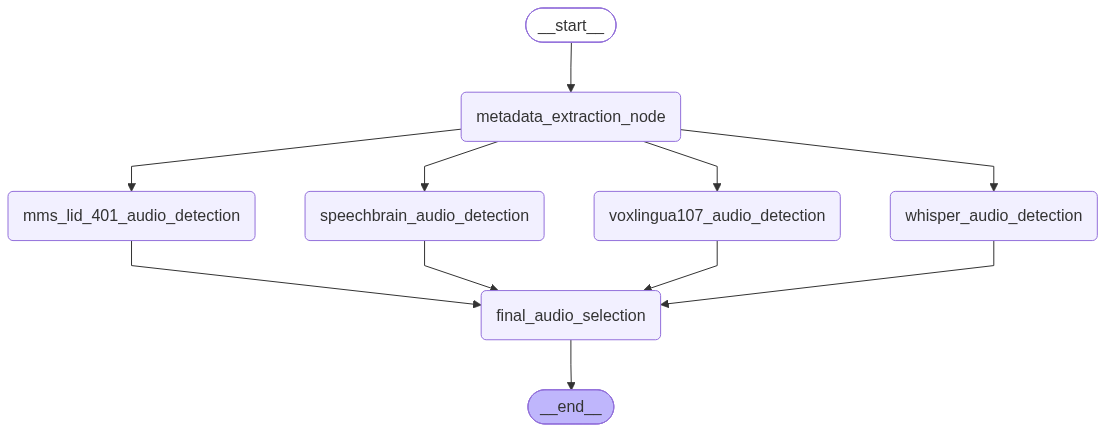

In [11]:
workflow

In [12]:
# 2. Sequential Pre-download step (Only needs to run once to download the zip files)
print("Checking/Downloading EasyOCR model files sequentially...")
use_gpu = torch.cuda.is_available()
easyocr.Reader(['en', 'hi'], gpu=use_gpu)
easyocr.Reader(['en', 'ur'], gpu=use_gpu)
print("EasyOCR models verified on disk!")

Using CPU. Note: This module is much faster with a GPU.


Checking/Downloading EasyOCR model files sequentially...


d:\factlens\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
Using CPU. Note: This module is much faster with a GPU.


EasyOCR models verified on disk!


In [23]:
initial_state = {"video_path" : "D:/factlens/video.mp4"}

final_state = workflow.invoke(initial_state)

print(final_state)

d:\factlens\.venv\Lib\site-packages\speechbrain\utils\fetching.py:153: UserWarning: Using SYMLINK strategy on Windows for fetching potentially requires elevated privileges and is not recommended. See `LocalStrategy` documentation.
  warnings.warn(
Using CPU. Note: This module is much faster with a GPU.
Using CPU. Note: This module is much faster with a GPU.


[VoxLingua Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-voxlingua107-ecapa\\snapshots\\0253049ae131d6a4be1c4f0d8b0ff483a0f8c8e9\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_vox\\hyperparams.yaml'[SpeechBrain Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-commonlanguage_ecapa\\snapshots\\9d809a7e1fdf48afa53e1b41ee8ae0af9ce46308\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_cv\\hyperparams.yaml'



Loading weights: 100%|██████████| 1098/1098 [00:00<00:00, 1216.68it/s]
Using CPU. Note: This module is much faster with a GPU.
Using CPU. Note: This module is much faster with a GPU.
Using CPU. Note: This module is much faster with a GPU.
Using CPU. Note: This module is much faster with a GPU.
d:\factlens\.venv\Lib\site-packages\speechbrain\dataio\dataloader.py:225: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self.__old_init__(loader, *args, **kwargs)
Using CPU. Note: This module is much faster with a GPU.
Using CPU. Note: This module is much faster with a GPU.


{'video_path': 'D:/factlens/video.mp4', 'valid': True, 'readable': True, 'filename': 'video.mp4', 'extension': '.mp4', 'mime_type': 'video/mp4', 'file_size_bytes': 5144107, 'file_size_mb': 4.91, 'duration_seconds': 49.57, 'fps': 30.0, 'frame_count': 1487, 'resolution': '360x640', 'whisper_result': {'audio_languages': ['hi'], 'ocr_languages': ['hi']}, 'mms_result': {'audio_languages': ['hi'], 'ocr_languages': ['hi']}, 'vox_result': {'audio_languages': [], 'ocr_languages': ['hi']}, 'speechbrain_result': {'audio_languages': [], 'ocr_languages': ['hi']}, 'audio_languages': ['hi'], 'ocr_languages': ['hi'], 'audio_path': 'temp1\\video.wav'}


In [16]:
print(final_state.get("audio_languages")[0])

hi
